<a href="https://colab.research.google.com/github/juandguerrero/megaline-revenue-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
# Cargar todas las librerías

from scipy import stats as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



## 1. Abrir los archivos de datos, estudiar la información general y preparar los datos

In [72]:
# Carga los archivos de datos en diferentes DataFrames
megaline_calls = pd.read_csv('megaline_calls.csv')
megaline_internet = pd.read_csv('megaline_internet.csv')
megaline_messages = pd.read_csv('megaline_messages.csv')
megaline_plans = pd.read_csv('megaline_plans.csv')
megaline_users = pd.read_csv('megaline_users.csv')

## Tarifas

In [73]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

megaline_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [74]:
# Imprime una muestra de los datos para las tarifas

megaline_plans.head()



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Usuarios/as

In [75]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

megaline_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [76]:
# Imprime una muestra de datos para usuarios

# Muestra aleatoria de 5 filas del dataframe original
print('Muestra aleatoria de 5 filas del dataframe original\n\n' )
print(megaline_users.sample(n=5))
print("\n\n\n")

# Muestra aleatoria de 5 filas del dataframe filtrado por las filas con valores presentes en la columna 'churn_date'
print("Muestra aleatoria de 5 filas del dataframe filtrado por las filas con valores presentes en la columna 'churn_date'\n\n" )
filtered_df = megaline_users[megaline_users['churn_date'].notnull()]
print(filtered_df.sample(n=5))
print("\n\n\n")

# Contar los valores duplicados en el dataset
print('Valores duplicados:',megaline_users.duplicated().sum())

Muestra aleatoria de 5 filas del dataframe original


     user_id first_name   last_name  age  \
446     1446   Pasquale        Ball   52   
355     1355      Digna       Tyson   57   
5       1005      Livia     Shields   31   
203     1203      Manie      Grimes   50   
190     1190       Troy  Hutchinson   56   

                                               city    reg_date      plan  \
446            Austin-Round Rock-Georgetown, TX MSA  2018-09-10      surf   
355          Los Angeles-Long Beach-Anaheim, CA MSA  2018-10-07      surf   
5               Dallas-Fort Worth-Arlington, TX MSA  2018-11-29      surf   
203              Boston-Cambridge-Newton, MA-NH MSA  2018-02-11      surf   
190  Virginia Beach-Norfolk-Newport News, VA-NC MSA  2018-08-01  ultimate   

    churn_date  
446        NaN  
355        NaN  
5          NaN  
203        NaN  
190        NaN  




Muestra aleatoria de 5 filas del dataframe filtrado por las filas con valores presentes en la columna 'churn_dat

In [77]:

# Cambiar el tipo de datos de las culumnas 'reg_date' y 'churn_date' a datetime

megaline_users['churn_date'] = pd.to_datetime(megaline_users['churn_date'])
megaline_users['reg_date'] = pd.to_datetime(megaline_users['reg_date'])


## Llamadas

In [78]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
megaline_calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [79]:
# Imprime una muestra de datos para las llamadas
print(megaline_calls.sample(n=5))


              id  user_id   call_date  duration
105561   1373_41     1373  2018-11-28      7.65
96458   1343_144     1343  2018-08-31      0.00
55599   1199_218     1199  2018-11-08      0.00
52958   1191_106     1191  2018-05-19      0.00
27938   1106_246     1106  2018-12-24      9.79


In [80]:
# Cambiar el tipo de datos de la culumna 'call_date' a datetime

megaline_calls['call_date'] = pd.to_datetime(megaline_calls['call_date'])



## Mensajes

In [81]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

megaline_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [82]:
# Imprime una muestra de datos para los mensajes

megaline_messages.sample(n=5)

,id,user_id,message_date
33593,1211_269,1211,2018-08-23
69591,1453_39,1453,2018-11-08
56508,1357_125,1357,2018-06-21
64287,1408_412,1408,2018-02-07
52748,1336_784,1336,2018-09-16


In [83]:
# Cambiar el tipo de datos de la culumna 'message_date' a datetime

megaline_messages['message_date'] = pd.to_datetime(megaline_messages['message_date'])

## Internet

In [84]:
# Imprime la información general/resumida sobre el DataFrame de internet

megaline_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [85]:
# Imprime una muestra de datos para el tráfico de internet

megaline_internet.sample(n=5)

,id,user_id,session_date,mb_used
87262,1404_129,1404,2018-10-12,587.13
16559,1074_73,1074,2018-12-20,741.37
77058,1361_87,1361,2018-08-05,250.75
8728,1046_13,1046,2018-07-17,272.70
57729,1261_181,1261,2018-07-24,0.00


In [86]:
# Cambiar el tipo de datos de la culumna 'session_date' a datetime

megaline_internet['session_date'] = pd.to_datetime(megaline_internet['session_date'])

## 2. Agrupar datos por usuario



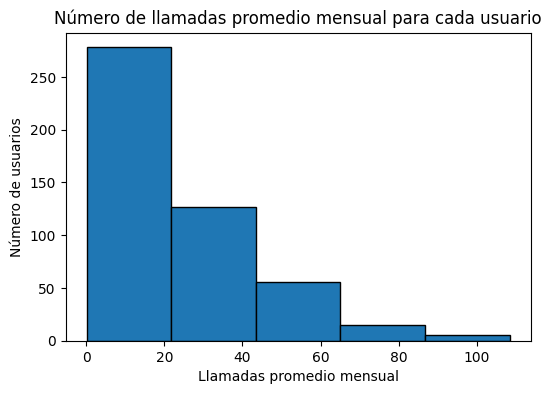

In [87]:
# Calcular el numero de llamadas promedio mensual para cada usuario
promedio_usuario = megaline_calls.groupby('user_id')['id'].count()
promedio_usuario = promedio_usuario / 12.
plt.figure(figsize=(6, 4))
plt.hist(promedio_usuario, bins=5, edgecolor='black')


plt.title('Número de llamadas promedio mensual para cada usuario')
plt.xlabel('Llamadas promedio mensual')
plt.ylabel('Número de usuarios')


plt.show()

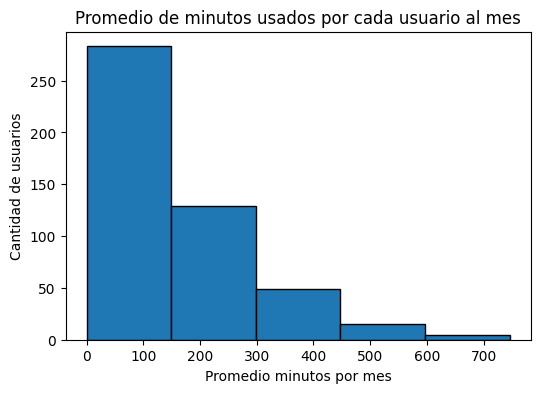

In [88]:
# Calcula la cantidad de minutos usados por cada usuario al mes.

minutos_usuario_mes = megaline_calls.groupby('user_id')['duration'].sum()
minutos_usuario_mes = minutos_usuario_mes / 12

# Crear un histograma de minutos_usuario_mes
plt.figure(figsize=(6, 4))
plt.hist(minutos_usuario_mes, bins=5, edgecolor='black')

plt.title("Promedio de minutos usados por cada usuario al mes")
plt.xlabel("Promedio minutos por mes")
plt.ylabel("Cantidad de usuarios")

plt.show()


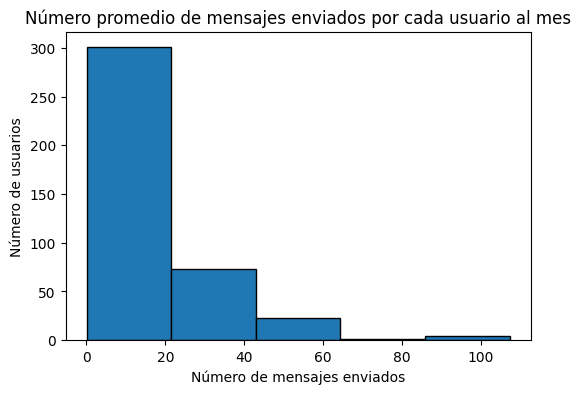

In [89]:
# Calcula el número de mensajes enviados por cada usuario al mes.

mensajes_usuario_mes = megaline_messages.groupby('user_id')['id'].count()
mensajes_usuario_mes = mensajes_usuario_mes / 12

# Crear un histograma de mensajes_usuario_mes
plt.figure(figsize=(6, 4))
plt.hist(mensajes_usuario_mes, bins=5, edgecolor='black')

plt.title("Número promedio de mensajes enviados por cada usuario al mes")
plt.xlabel("Número de mensajes enviados")
plt.ylabel("Número de usuarios")

plt.show()

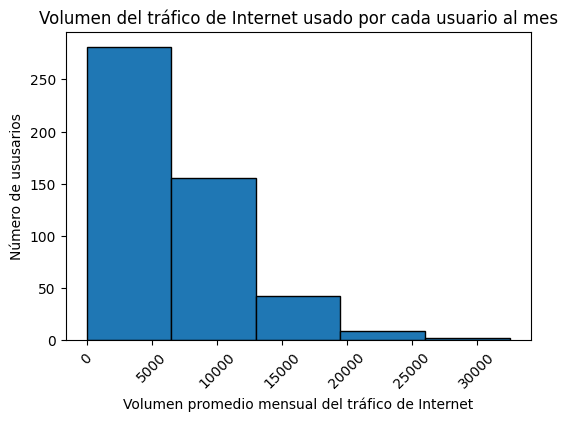

In [90]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes.

tráfico_usuario_mes = megaline_internet.groupby('user_id')['mb_used'].sum()
tráfico_usuario_mes = tráfico_usuario_mes/12

# Crear un histograma de tráfico_usuario_mes
plt.figure(figsize=(6, 4))
plt.hist(tráfico_usuario_mes, bins=5, edgecolor='black')

plt.title("Volumen del tráfico de Internet usado por cada usuario al mes")
plt.xlabel("Volumen promedio mensual del tráfico de Internet")
plt.ylabel("Número de ususarios")
plt.xticks(rotation=45)

plt.show()

In [91]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

# Crear una columna 'month' para cada dataframe
megaline_calls['month'] = megaline_calls['call_date'].dt.to_period('M')
megaline_messages['month'] = megaline_messages['message_date'].dt.to_period('M')
megaline_internet['month'] = megaline_internet['session_date'].dt.to_period('M')

# Agrupar cada dataframe por user_id and month

# Total minutos y número de llamadas
megaline_calls['duration'] = np.ceil(megaline_calls['duration'])
calls_per_month = megaline_calls.groupby(['user_id', 'month']).agg(
    calls_count=('id', 'count'),
    total_minutes=('duration', 'sum')
).reset_index()


# Número de mensajes
messages_per_month = megaline_messages.groupby(['user_id', 'month']).agg(
    messages_count=('id', 'count')
).reset_index()

# Total datos gastados
internet_per_month = megaline_internet.groupby(['user_id', 'month']).agg(
    mb_used=('mb_used', 'sum')
).reset_index()
internet_per_month['mb_used'] = np.ceil(internet_per_month['mb_used'] / 1024)

# Unir todos los datasets
merged_data = calls_per_month.merge(messages_per_month, on=['user_id', 'month'], how='outer')
merged_data = merged_data.merge(internet_per_month, on=['user_id', 'month'], how='outer')

# Reemplazar NaN con 0
merged_data = merged_data.fillna(0)


print(merged_data.head())





   user_id    month  calls_count  total_minutes  messages_count  mb_used
0     1000  2018-12         16.0          124.0            11.0      2.0
1     1001  2018-08         27.0          182.0            30.0      7.0
2     1001  2018-09         49.0          315.0            44.0     14.0
3     1001  2018-10         65.0          393.0            53.0     22.0
4     1001  2018-11         64.0          426.0            36.0     19.0


      user_id    month  calls_count  total_minutes  messages_count  mb_used  \
0        1000  2018-12         16.0          124.0            11.0      2.0   
1        1001  2018-08         27.0          182.0            30.0      7.0   
2        1001  2018-09         49.0          315.0            44.0     14.0   
3        1001  2018-10         65.0          393.0            53.0     22.0   
4        1001  2018-11         64.0          426.0            36.0     19.0   
...       ...      ...          ...            ...             ...      ...   
2288     1498  2018-12         39.0          339.0             0.0     23.0   
2289     1499  2018-09         41.0          346.0             0.0     13.0   
2290     1499  2018-10         53.0          385.0             0.0     20.0   
2291     1499  2018-11         45.0          308.0             0.0     17.0   
2292     1499  2018-12         65.0          496.0             0.0     22.0   

          plan  monthly income  
0     ultimate    

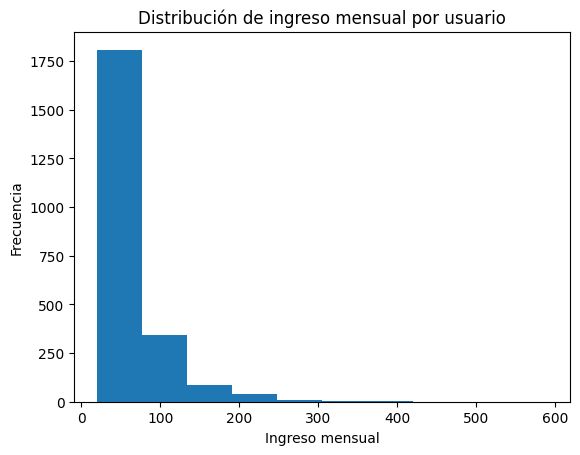

In [92]:
# Calcula el ingreso mensual para cada usuario

# Agregar la columna plan a el dataframe de llamadas, minutos, mensajes
# e Internet con base en user_id y month

new_users = megaline_users[['user_id', 'plan']]
users_plan = merged_data.merge(new_users, on=['user_id'], how='left')

users_plan['monthly income'] = 0.0  # crear una columna para el ingreso mensual

# tarifa base para usuarios 'surf'
users_plan.loc[users_plan['plan'] == 'surf', 'monthly income'] = 20

# cargo extra para minutos mayores a 500
users_plan.loc[
    (users_plan['total_minutes'] > 500) & (users_plan['plan'] == 'surf'),
    'monthly income'
] += (users_plan['total_minutes'] - 500) * 0.03

# cargo extra para mensajes mayores a 50
users_plan.loc[
    (users_plan['messages_count'] > 50) & (users_plan['plan'] == 'surf'),
    'monthly income'
] += (users_plan['messages_count'] - 50) * 0.03

# cargo extra para datos mayores a 15 GB
users_plan.loc[
    (users_plan['mb_used'] > 15) & (users_plan['plan'] == 'surf'),
    'monthly income'
] += (users_plan['mb_used'] - 15) * 10

# tarifa base para usuarios 'ultimate'
users_plan.loc[users_plan['plan'] == 'ultimate', 'monthly income'] = 70

# cargo extra para minutos mayores a 3000
users_plan.loc[
    (users_plan['total_minutes'] > 3000) & (users_plan['plan'] == 'ultimate'),
    'monthly income'
] += (users_plan['total_minutes'] - 3000) * 0.01

# cargo extra para mensajes mayores a 1000
users_plan.loc[
    (users_plan['messages_count'] > 1000) & (users_plan['plan'] == 'ultimate'),
    'monthly income'
] += (users_plan['messages_count'] - 1000) * 0.01

# cargo extra para datos mayores a 30 GB
users_plan.loc[
    (users_plan['mb_used'] > 30) & (users_plan['plan'] == 'ultimate'),
    'monthly income'
] += (users_plan['mb_used'] - 30) * 7

print(users_plan)


# crear histograma de ingreso mensual para cada usuario

plt.hist(users_plan['monthly income'], bins=10)
plt.title('Distribución de ingreso mensual por usuario')
plt.xlabel('Ingreso mensual')
plt.ylabel('Frecuencia')
plt.show()



## 3. Analiza los datos

### Llamadas

/tmp/ipykernel_527/3046597666.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_duration = users_plan.groupby(['plan', 'month']).apply(


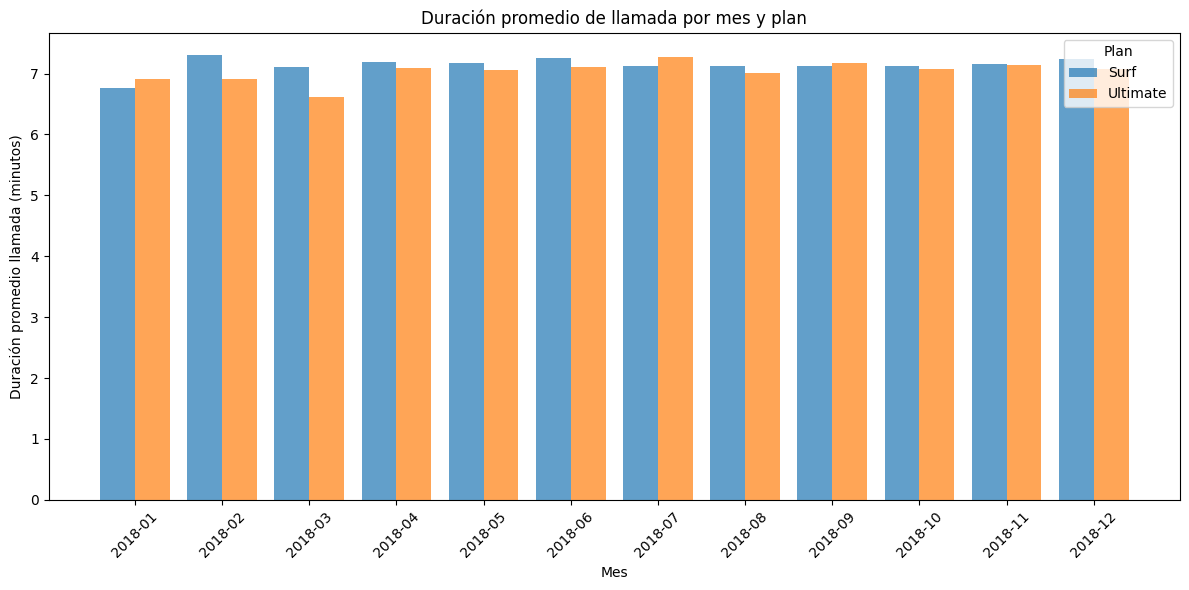

In [93]:


# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

# Agrupar por plan y month y calcular el promedio de duración de cada llamada
avg_duration = users_plan.groupby(['plan', 'month']).apply(
    lambda x: x['total_minutes'].sum() / x['calls_count'].sum()
).reset_index(name='avg_call_duration')

# Convertir 'month' a string para que matplotlib pueda graficarlo
avg_duration['month'] = avg_duration['month'].astype(str)

# Separar los datos para cada plan
surf = avg_duration[avg_duration['plan'] == 'surf']
ultimate = avg_duration[avg_duration['plan'] == 'ultimate']

# Ordenar los dataframes creados anteriormente por la columna month
surf = surf.sort_values('month').reset_index(drop=True)
ultimate = ultimate.sort_values('month').reset_index(drop=True)

# Dibuja ambos planos (uno al lado del otro)

plt.figure(figsize=(12, 6))

x = range(len(surf))
bar_width = 0.4

plt.bar([i - bar_width/2 for i in x], surf['avg_call_duration'], width=bar_width, label='Surf', alpha=0.7)
plt.bar([i + bar_width/2 for i in x], ultimate['avg_call_duration'], width=bar_width, label='Ultimate', alpha=0.7)

plt.title('Duración promedio de llamada por mes y plan')
plt.xlabel('Mes')
plt.ylabel('Duración promedio llamada (minutos)')
plt.xticks(x, surf['month'], rotation=45)
plt.legend(title='Plan')
plt.tight_layout()

plt.show()






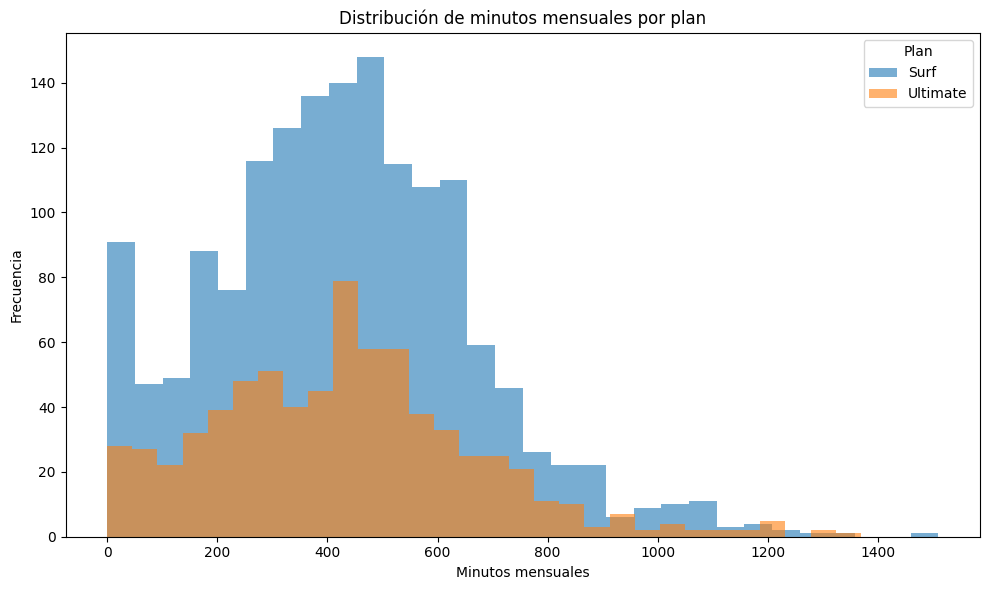

In [94]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.


# Crear histograma
plt.figure(figsize=(10, 6))

# Representar ambos planes en el mismo gráfico
plt.hist(
    users_plan[users_plan['plan'] == 'surf']['total_minutes'],
    bins=30, alpha=0.6, label='Surf'
)

plt.hist(
    users_plan[users_plan['plan'] == 'ultimate']['total_minutes'],
    bins=30, alpha=0.6, label='Ultimate'
)


plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos mensuales')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.tight_layout()

plt.show()


In [95]:
# Calcula la media y la varianza de la duración mensual de llamadas.

mean_duration = users_plan['total_minutes'].mean()
variance_duration = users_plan['total_minutes'].var()

print(f"Media de la duración mensual de llamadas: {mean_duration:.2f} minutos")
print(f"Varianza de la duración mensual de llamadas: {variance_duration:.2f}")



Media de la duración mensual de llamadas: 429.28 minutos
Varianza de la duración mensual de llamadas: 55847.18


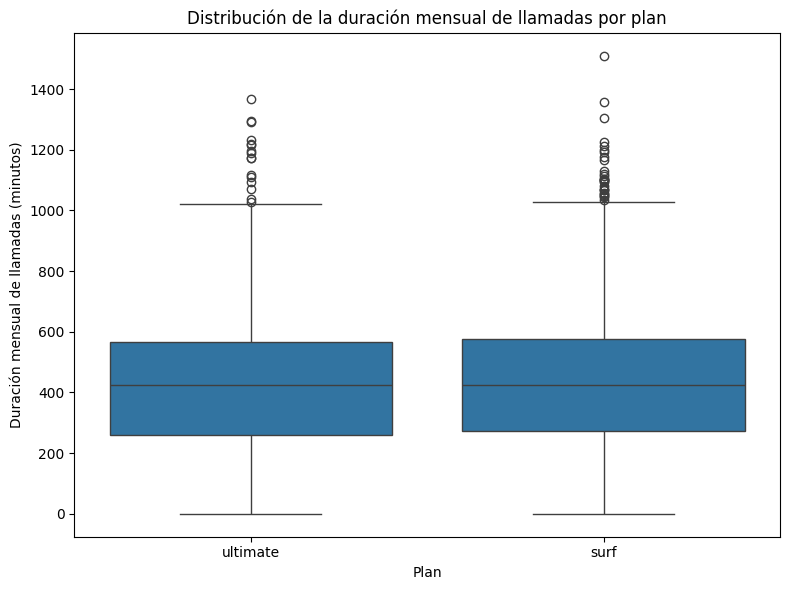

In [96]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='total_minutes', data=users_plan)

plt.title('Distribución de la duración mensual de llamadas por plan')
plt.xlabel('Plan')
plt.ylabel('Duración mensual de llamadas (minutos)')
plt.tight_layout()
plt.show()

**Conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?**

La duración promedio de cada llamada es muy similar para los dos planes a lo largo de todo el ano.   

Hay muchos mas usuarios del plan surf.

Ambos planes presentan muchos valores outliers hacia la derecha en la duración mensual de llamadas.

Ningún usuario del plan ultimate excedió la cantidad de minutos del plan base. Muchos usuarios del plan surf excedieron la cantidad de minutos del plan base.





### Mensajes

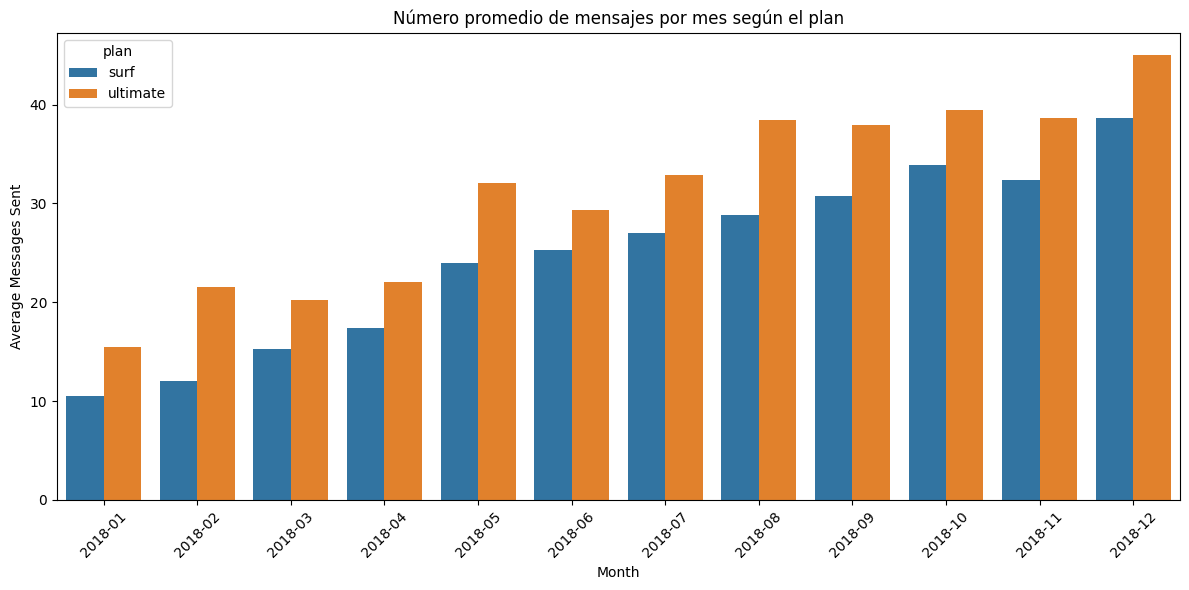

In [97]:

# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

# Agrupamos por plan y mes, y calculamos el promedio de mensajes enviados
mensajes_por_plan_mes = (
    users_plan.groupby(['plan', 'month'])['messages_count']
      .mean()
      .reset_index()
      .sort_values(by=['plan', 'month'])
)

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    data=mensajes_por_plan_mes,
    x='month',
    y='messages_count',
    hue='plan'
)

plt.title('Número promedio de mensajes por mes según el plan')
plt.xlabel('Month')
plt.ylabel('Average Messages Sent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





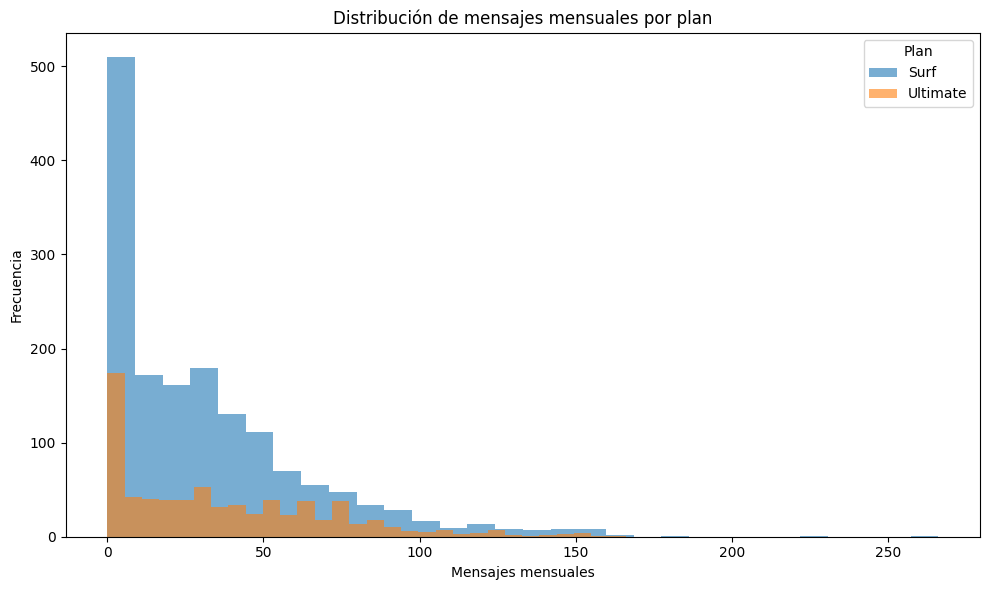

In [98]:
# Compara el número de mensajes mensuales que necesitan los usuarios de cada plan. Traza un histograma.

# Crear histograma
plt.figure(figsize=(10, 6))

# Representar ambos planes en el mismo gráfico
plt.hist(
    users_plan[users_plan['plan'] == 'surf']['messages_count'],
    bins=30, alpha=0.6, label='Surf'
)

plt.hist(
    users_plan[users_plan['plan'] == 'ultimate']['messages_count'],
    bins=30, alpha=0.6, label='Ultimate'
)


plt.title('Distribución de mensajes mensuales por plan')
plt.xlabel('Mensajes mensuales')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.tight_layout()

plt.show()



Media de el número de mensajes mensuales: 33.166593981683384 mensajes
Varianza de el número de mensajes mensuales: 1160.7706636557532


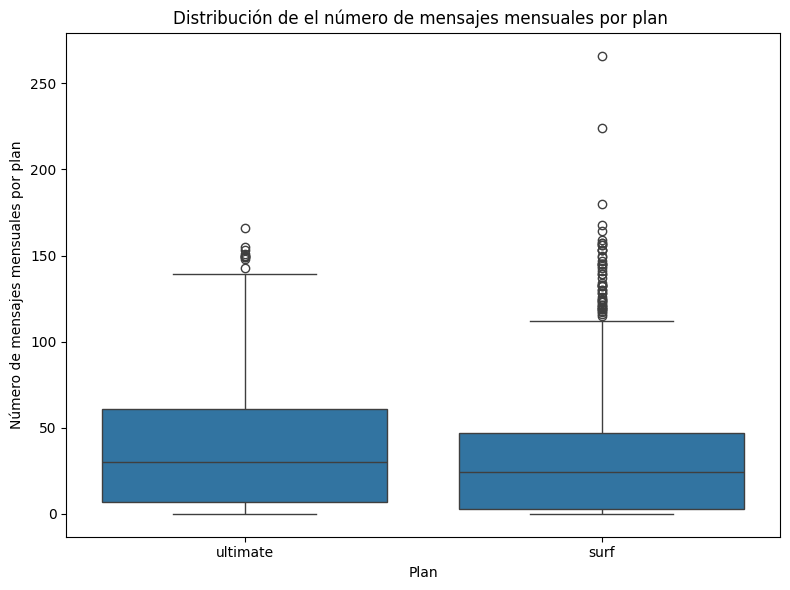

In [99]:
# Calcula la media y la varianza de el número de mensajes mensuales

mean_duration_mensajes = users_plan['messages_count'].mean()
variance_duration_mensajes = users_plan['messages_count'].var()

print(f"Media de el número de mensajes mensuales: {mean_duration_mensajes} mensajes")
print(f"Varianza de el número de mensajes mensuales: {variance_duration_mensajes}")

# Traza un diagrama de caja para visualizar la distribución del número de mensajes mensuales

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='messages_count', data=users_plan)

plt.title('Distribución de el número de mensajes mensuales por plan ')
plt.xlabel('Plan')
plt.ylabel('Número de mensajes mensuales por plan')
plt.tight_layout()
plt.show()

**Conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes**

El número promedio de mensajes mensuales aumentó de manera continua para ambos planes a lo largo el ano.

El número promedio de mensajes mensuales fue un poco más alto para el plan ultimate en todos los meses.

Nigún usuario del plan ultimate superó los 1000 mensajes del plan base, todos estuvieron muy lejos de esa cifra.

La cantidad de mensajes enviados más alta para los dos planes fue de valores cercanos a cero, lo que indica due hay una gran cantidad de usuarious  de ambos planes que no usan los mensajes para nada.

En ambos planes hay usuarios que sobrepasan el número típico de mensajes mensuales consumidos. La cantidad de estos usuarios es mayor y mas dispersa en el plan surf.





### Internet

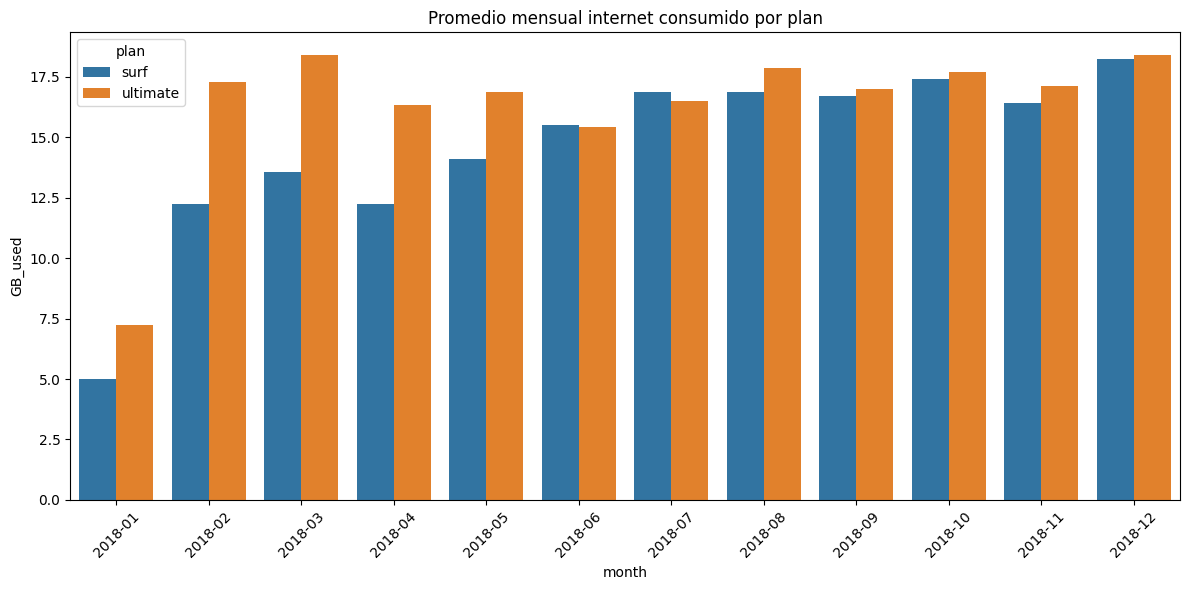

In [100]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

trafico_por_plan = (
    users_plan.groupby(['plan', 'month'])['mb_used']
      .mean()
      .reset_index()
      .sort_values(by=['plan', 'month'])
)

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    data=trafico_por_plan,
    x='month',
    y='mb_used',
    hue='plan'
)

plt.title('Promedio mensual internet consumido por plan')
plt.xlabel('month')
plt.ylabel('GB_used')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


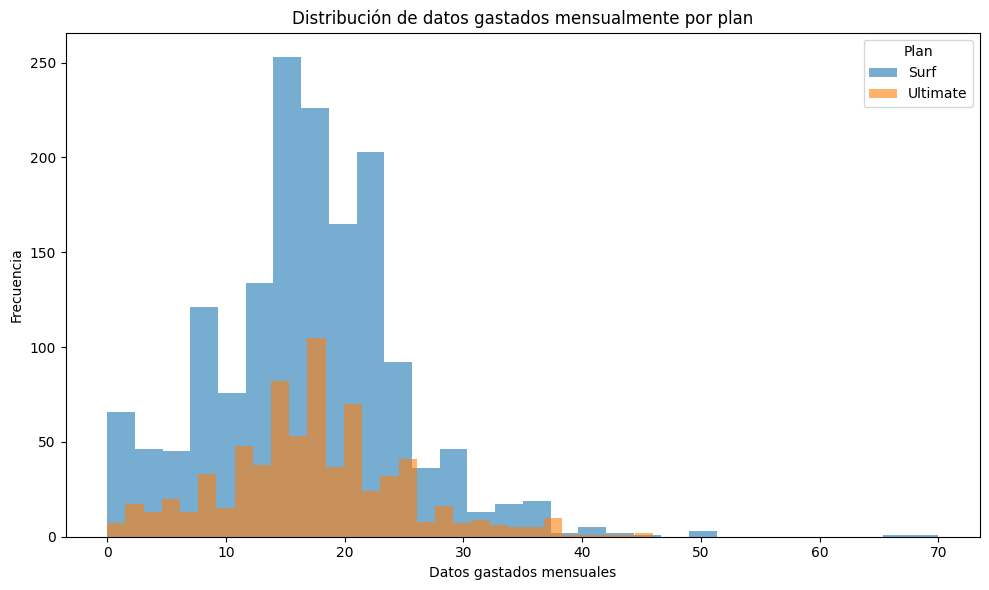

Media de los datos gastados mensualmente: 16.870475359790667
Varianza de los datos gastados mensualmente: 60.78033646677929


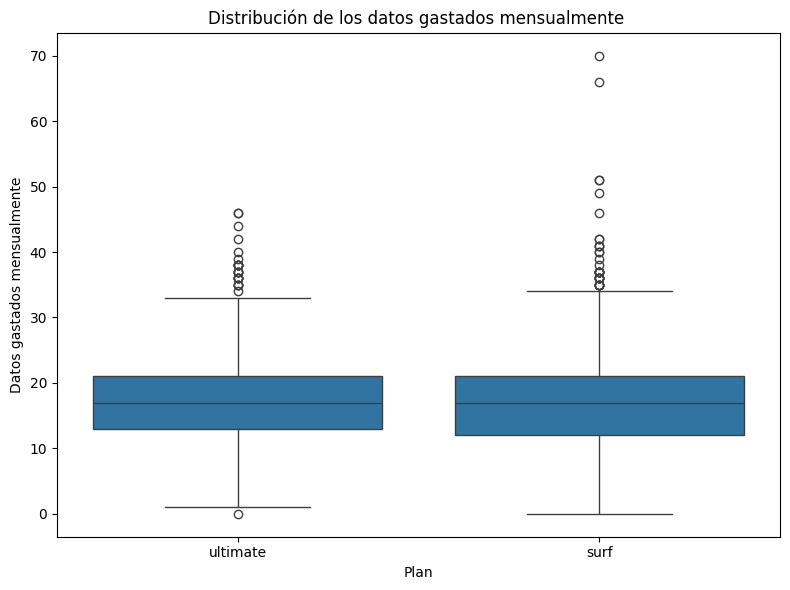

In [101]:
# Compara el número de datos gastados mensuales que necesitan los usuarios de cada plan. Traza un histograma.

# Crear histograma
plt.figure(figsize=(10, 6))

# Representar ambos planes en el mismo gráfico
plt.hist(
    users_plan[users_plan['plan'] == 'surf']['mb_used'],
    bins=30, alpha=0.6, label='Surf'
)

plt.hist(
    users_plan[users_plan['plan'] == 'ultimate']['mb_used'],
    bins=30, alpha=0.6, label='Ultimate'
)

plt.title('Distribución de datos gastados mensualmente por plan')
plt.xlabel('Datos gastados mensuales')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.tight_layout()

plt.show()


# Calcula la media y la varianza de los datos gastados mensualmente

mean_duration_datos = users_plan['mb_used'].mean()
variance_duration_datos = users_plan['mb_used'].var()

print(f"Media de los datos gastados mensualmente: {mean_duration_datos}")
print(f"Varianza de los datos gastados mensualmente: {variance_duration_datos}")

# Traza un diagrama de caja para visualizar la distribución de los datos gastados mensualmente

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='mb_used', data=users_plan)

plt.title('Distribución de los datos gastados mensualmente ')
plt.xlabel('Plan')
plt.ylabel('Datos gastados mensualmente')
plt.tight_layout()
plt.show()

**Conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet.**

El promedio mensual de internet consumido fue significativamente mas bajo para ambos planes en el primer mes del ano.

Una gran cantidad de los usuarios del plan surf sobrepasaron los datos del plan base.

Algunos usuarios del plan ultimate sobrepasaron los dates del plan base.

La distribución de datos gastados mensualmente por plan para ambos planes está sesgada ligeramente a la derecha.

Hay valores atípicos hacia la derecha en la distribution de los datos gastados mensualmente para ambos planes. Pero hay más y más dispersos en el plan surf.


## Ingreso

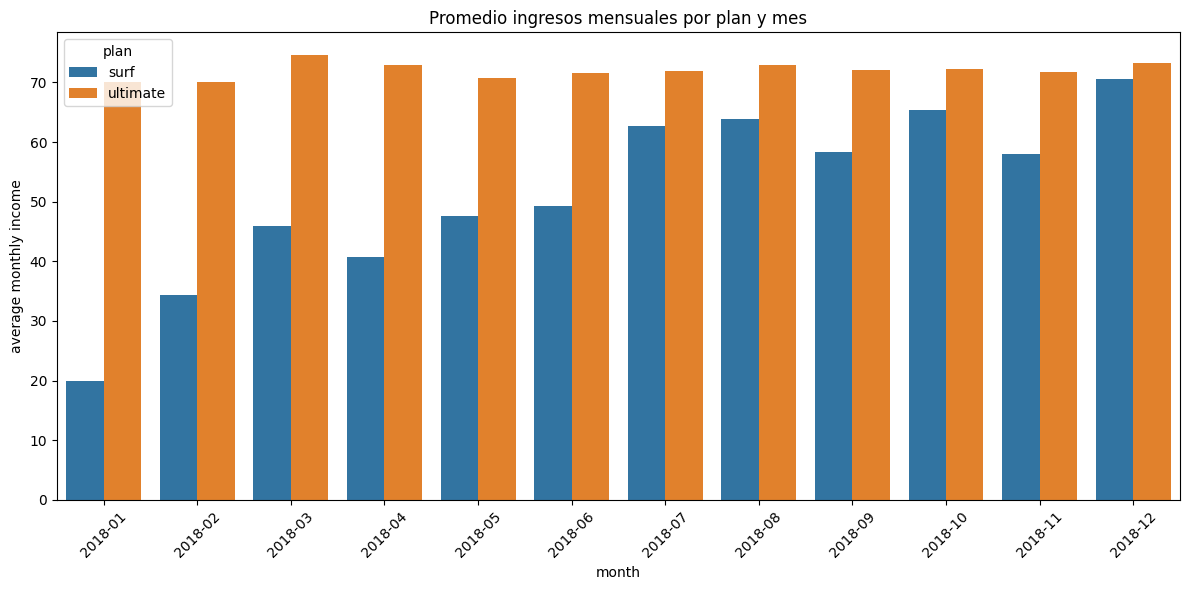

In [103]:
# Compara la cantidad de ingresos mensuales consumido por usuarios por plan

ingresos_por_plan = (
    users_plan.groupby(['plan', 'month'])['monthly income']
      .mean()
      .reset_index()
      .rename(columns={'monthly income': 'average monthly income'})
      .sort_values(by=['plan', 'month'])
)

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    data=ingresos_por_plan,
    x='month',
    y='average monthly income',
    hue='plan'
)

plt.title('Promedio ingresos mensuales por plan y mes')
plt.xlabel('month')
plt.ylabel('average monthly income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



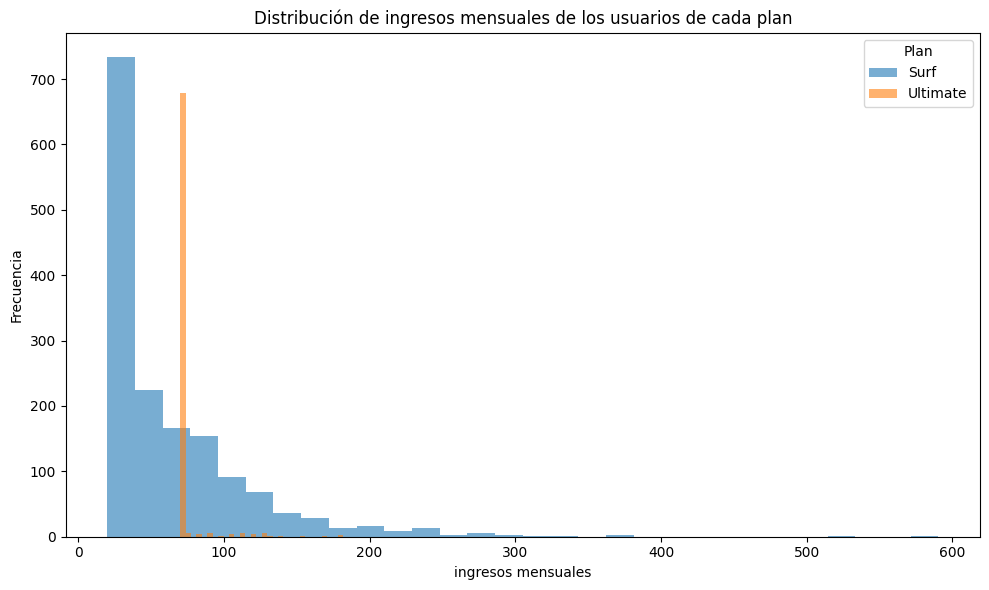

Media de los ingresos mensuales: 64.3511469690362
Varianza de los ingresos mensuales: 2173.8855276978406


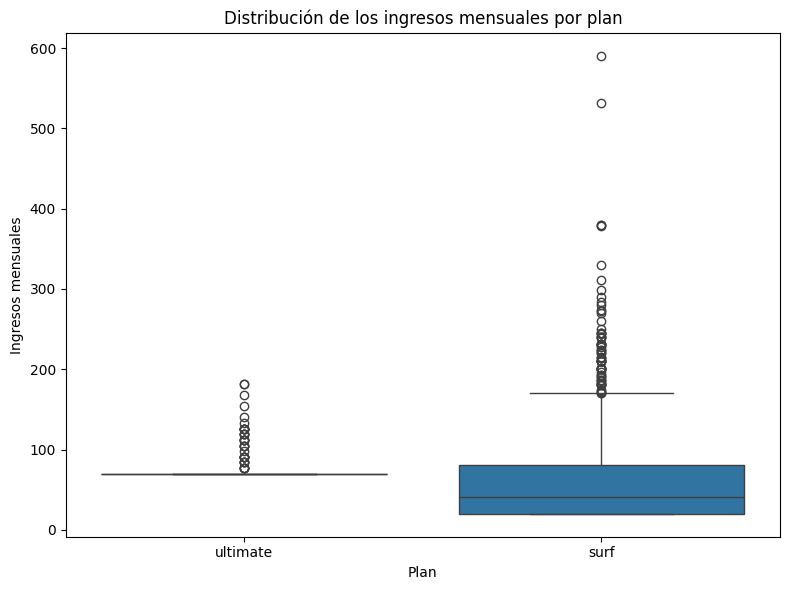

In [104]:
# Compara los ingresos mensuales de los usuarios de cada plan. Traza un histograma.

# Crear histograma
plt.figure(figsize=(10, 6))

# Representar ambos planes en el mismo gráfico
plt.hist(
    users_plan[users_plan['plan'] == 'surf']['monthly income'],
    bins=30, alpha=0.6, label='Surf'
)

plt.hist(
    users_plan[users_plan['plan'] == 'ultimate']['monthly income'],
    bins=30, alpha=0.6, label='Ultimate'
)

plt.title('Distribución de ingresos mensuales de los usuarios de cada plan')
plt.xlabel('ingresos mensuales')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.tight_layout()

plt.show()

# Calcula la media y la varianza de los ingresos mensuales

mean_duration_ingresos = users_plan['monthly income'].mean()
variance_duration_ingresos = users_plan['monthly income'].var()

print(f"Media de los ingresos mensuales: {mean_duration_ingresos}")
print(f"Varianza de los ingresos mensuales: {variance_duration_ingresos}")

# Traza un diagrama de caja para visualizar la distribución de los ingresos mensuales por plan

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='monthly income', data=users_plan)

plt.title('Distribución de los ingresos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Ingresos mensuales')
plt.tight_layout()
plt.show()

**Conclusiones sobre cómo difiere el ingreso entre los planes**

El ingreso promedio del plan ultimate se mantuvo prácticamente igual a lo largo de todo el ano.

El ingreso promedio del plan surf tuvo tuna tendencia ascendente a lo largo de todo el ano.

Para ambos planes, la mayoría de los ingress se concentra cerca  de los valores de los planes base.

Hay muchos menos usuarios del plan ultimate

En el plan Surf, los ingresos son muy variables, muchos usuarios pagan poco y algunos pagan muchísimo.

En el plan Ultimate, los ingresos son estables y altos, casi todos los usuarios pagan valores similares, no se ven grandes outliers.


## 4. Prueba las hipótesis estadísticas

In [105]:
# Separar los datos por plan
surf_income = users_plan[users_plan['plan'] == 'surf']['monthly income']
ultimate_income = users_plan[users_plan['plan'] == 'ultimate']['monthly income']

# Prueba de Levene (igualdad de varianzas)
levene_stat, levene_p = st.levene(surf_income, ultimate_income, center='mean')

print(f"Levene p-value (igualdad de varianzas): {levene_p:.5f}")

# Determinar si las varianzas son iguales
if levene_p < 0.05:
    equal_var_assumption = False
    print("Conclusión Levene: Las varianzas son diferentes → usar t-test de Welch.")
else:
    equal_var_assumption = True
    print("Conclusión Levene: Las varianzas son iguales → usar t-test estándar.")


# Prueba t con selección automática del tipo
t_stat, p_value = st.ttest_ind(surf_income, ultimate_income, equal_var=equal_var_assumption)

print(f"\nT-test p-value: {p_value:.5f}")
print(f"T-statistic: {t_stat:.5f}")

# Verificación de NaN
if pd.isna(p_value):
    print("\n Advertencia: El p-value es NaN. Revisa los datos: puede haber valores vacíos, constantes o problemas en el cálculo.")
else:
    if p_value < 0.05:
        print("\n Rechazar H₀ → Los ingresos promedio son significativamente diferentes entre los planes.")
    else:
        print("\n No se rechaza H₀ → No hay evidencia de diferencia significativa entre los ingresos promedio.")





Levene p-value (igualdad de varianzas): 0.00000
Conclusión Levene: Las varianzas son diferentes → usar t-test de Welch.

T-test p-value: 0.00000
T-statistic: -7.95209

 Rechazar H₀ → Los ingresos promedio son significativamente diferentes entre los planes.


In [106]:
# Prueba de hipótesis: comparación de ingresos NY vs resto

# Agregar al dataframe compilado la columna de city
users_city = megaline_users[['user_id', 'city']]
users_plan = users_plan.merge(users_city, on='user_id', how='left')

# Dividir los datos según ciudad
ny_users = users_plan[
    users_plan['city'].str.contains('New York-Newark-Jersey City', case=False, na=False)
]
other_users = users_plan[
    ~users_plan['city'].str.contains('New York-Newark-Jersey City', case=False, na=False)
]

# Extraer los ingresos
ny_income = ny_users['monthly income']
other_income = other_users['monthly income']

# Prueba de Levene para igualdad de varianzas
levene_stat, levene_p = st.levene(ny_income, other_income, center='median')
print(f"Levene p-value: {levene_p}")

# Decidir si usar varianzas iguales o no
equal_var_setting = True if levene_p > 0.05 else False

print(f"Equal_var usado en la t-test: {equal_var_setting}")

# Prueba t (dependiendo de Levene)
t_stat, p_value = st.ttest_ind(ny_income, other_income, equal_var=equal_var_setting)

print(f"t-statistic: {t_stat}")
print(f"p-value t-test: {p_value}")

# Comprobación por si aparece NaN
if pd.isna(p_value):
    print("El p-value es NaN → revisa si hay valores vacíos, constantes o problemas en los datos.")
elif p_value < 0.05:
    print("Rechazar H₀ → existe diferencia significativa en el ingreso promedio entre usuarios de NY-NJ y los demás.")
else:
    print("No se rechaza H₀ → no hay diferencia significativa en los ingresos promedio.")





Levene p-value: 0.12580091109612837
Equal_var usado en la t-test: True
t-statistic: -2.0194429818968103
p-value t-test: 0.043557431621342436
Rechazar H₀ → existe diferencia significativa en el ingreso promedio entre usuarios de NY-NJ y los demás.


## 5. Conclusión general

Los usuarios de ambos planes utilizan de forma similar las llamadas y los mensajes, aunque el plan Surf tiene muchos más usuarios y presenta un consumo más irregular. En Surf, una gran proporción de clientes excede los minutos y los datos incluidos, lo que provoca ingresos muy variables: muchos pagan poco, pero algunos pagan montos muy altos, generando una tendencia creciente en los ingresos promedio a lo largo del año.

En contraste, los usuarios del plan Ultimate casi nunca exceden los límites y generan ingresos estables y elevados, sin grandes variaciones entre meses. Esto refleja un comportamiento más predecible y homogéneo, aunque con una base de usuarios mucho menor.

Ambos planes muestran outliers en llamadas, mensajes y datos, pero estos son mucho más frecuentes y dispersos en Surf. Además, en ambos planes los ingresos se concentran cerca del valor base, indicando que la mayoría de los usuarios no sobrepasan significativamente los límites incl⁠uidos.

En conjunto, puede concluirse que Ultimate ofrece ingresos más constantes y altos, mientras que Surf genera ingresos más volátiles pero con potencial de crecimiento debido a los excedentes de uso.
